In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import recall_score,precision_score, f1_score
import warnings
warnings.filterwarnings("ignore")

In [226]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

In [227]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [229]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [230]:
df["Heart Disease"] = df["Heart Disease"].map({"Presence" : 1, "Absence" : 0})

In [231]:
df.shape


(270, 14)

In [232]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


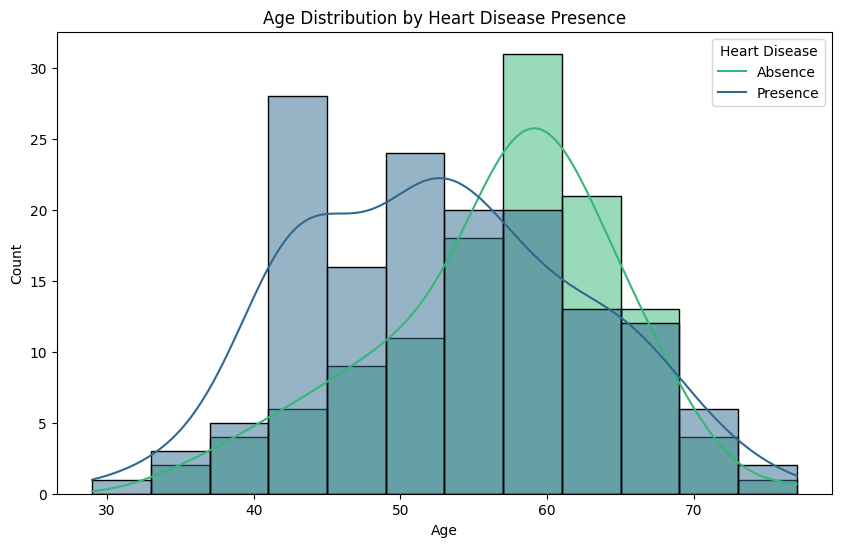

In [233]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Heart Disease', kde=True, palette='viridis')
plt.title('Age Distribution by Heart Disease Presence')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['Absence', 'Presence'])
plt.show()

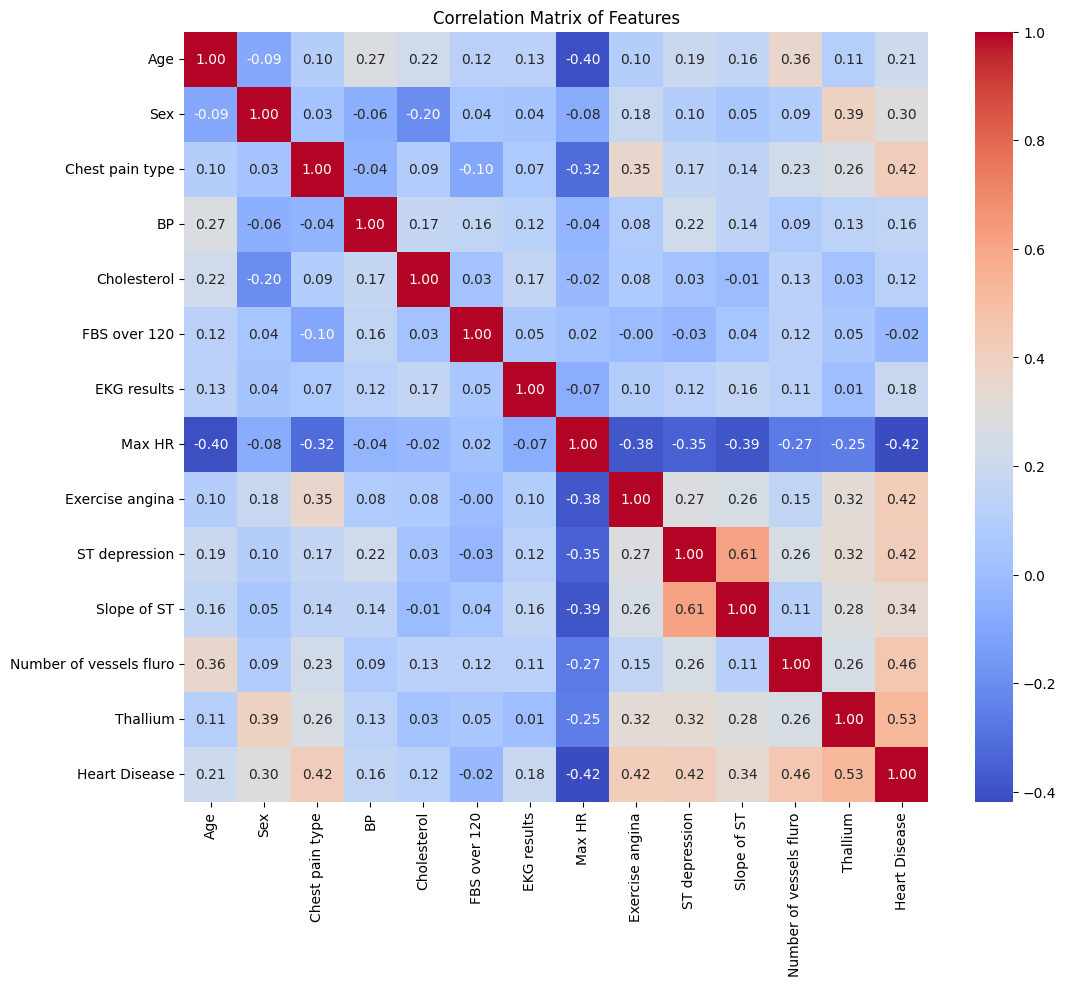

In [234]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

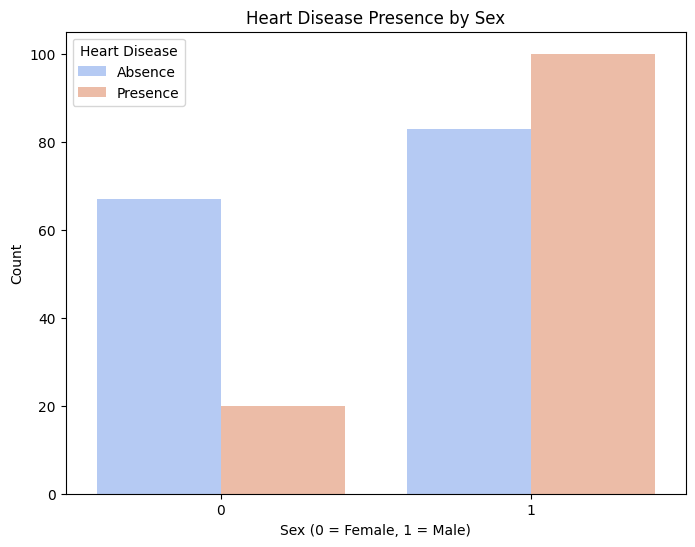

In [235]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sex', hue='Heart Disease', palette='coolwarm')
plt.title('Heart Disease Presence by Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['Absence', 'Presence'])
plt.show()

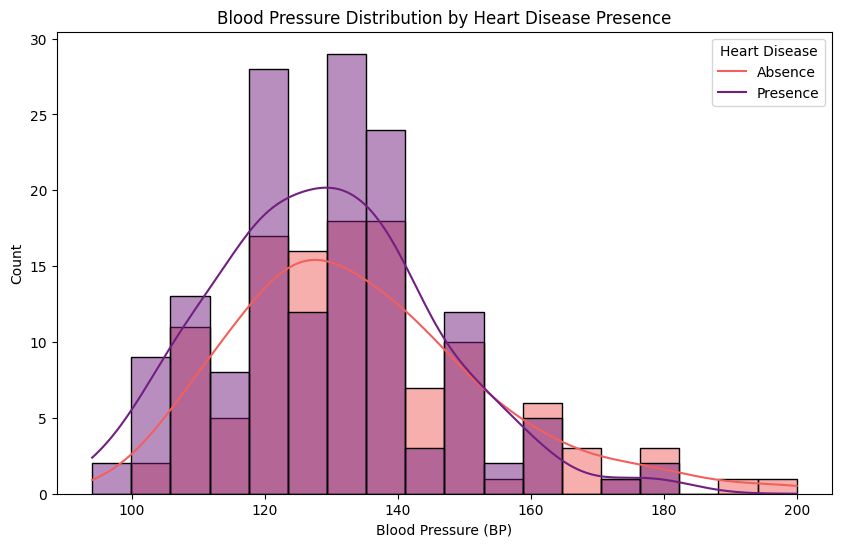

In [236]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='BP', hue='Heart Disease', kde=True, palette='magma')
plt.title('Blood Pressure Distribution by Heart Disease Presence')
plt.xlabel('Blood Pressure (BP)')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['Absence', 'Presence'])
plt.show()

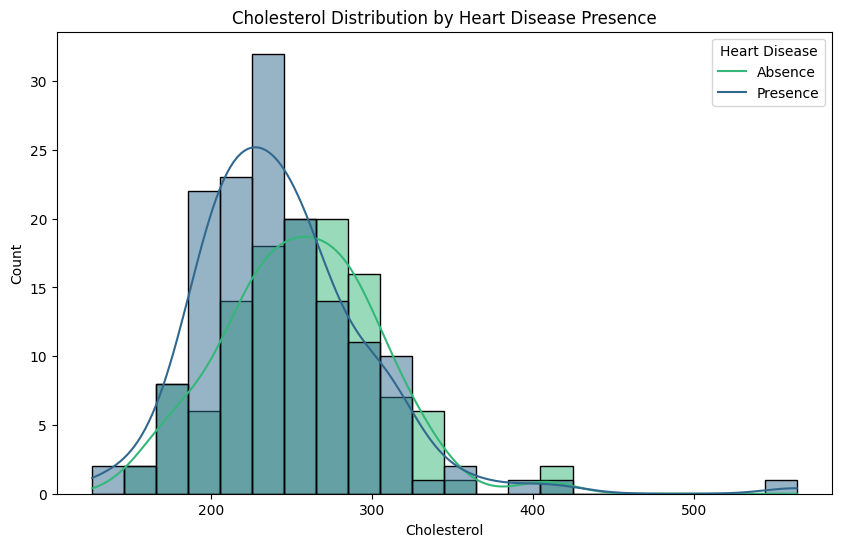

In [237]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Cholesterol', hue='Heart Disease', kde=True, palette='viridis')
plt.title('Cholesterol Distribution by Heart Disease Presence')
plt.xlabel('Cholesterol')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['Absence', 'Presence'])
plt.show()

In [238]:
df.columns
print(df.head())

   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium  Heart Disease  
0                        3         3              1  
1                        0         7              0  
2                        0

In [239]:
arr=df.columns
for i in arr:
    print(df[i].value_counts())


Age
54    16
58    15
60    12
59    12
57    12
51    12
62    11
52    11
44    10
64     9
56     9
41     9
65     8
67     8
42     8
50     7
43     7
46     7
63     7
48     7
45     7
53     7
61     7
66     6
55     6
49     5
70     4
47     4
69     3
68     3
40     3
71     3
39     3
35     3
37     2
34     2
74     1
76     1
38     1
77     1
29     1
Name: count, dtype: int64
Sex
1    183
0     87
Name: count, dtype: int64
Chest pain type
4    129
3     79
2     42
1     20
Name: count, dtype: int64
BP
120    34
130    31
140    30
110    17
150    17
160    11
125    10
112     9
138     9
128     9
118     7
135     6
108     6
132     6
124     5
145     5
100     4
134     4
152     4
142     3
115     3
136     3
105     3
126     3
180     3
122     3
170     2
178     2
94      2
102     2
101     1
104     1
106     1
156     1
174     1
144     1
146     1
165     1
148     1
158     1
200     1
192     1
117     1
123     1
129     1
155     1
172     1
Na

In [240]:
scaler = StandardScaler()

In [241]:
X = df.drop(columns=["Heart Disease"],axis=1)
y = df["Heart Disease"]

In [242]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=42)

In [243]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [244]:
result = []

In [245]:
#Logistic Regression

from sklearn.metrics import f1_score, recall_score, precision_score # Re-import to ensure functions are correctly referenced

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_log_reg)
confusion_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
f1_score_lr = f1_score(y_test, y_pred_log_reg)
recall_score_lr = recall_score(y_test, y_pred_log_reg)
precision_score_lr = precision_score(y_test, y_pred_log_reg)
result.append(["Logistic Regression", accuracy_lr, f1_score_lr, recall_score_lr, precision_score_lr])
print("Logistic Regression Model is trained.")

Logistic Regression Model is trained.


In [246]:
print(confusion_matrix_log_reg)

[[46  3]
 [11 21]]


In [247]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
confusion_matrix_knn = confusion_matrix(y_test, y_pred_knn)
f1_score_knn = f1_score(y_test, y_pred_knn)
recall_score_knn = recall_score(y_test, y_pred_knn)
precision_score_knn = precision_score(y_test, y_pred_knn)
result.append(["KNN", accuracy_knn, f1_score_knn, recall_score_knn, precision_score_knn])

In [248]:
result

[['Logistic Regression', 0.8271604938271605, 0.75, 0.65625, 0.875],
 ['KNN', 0.7901234567901234, 0.7017543859649122, 0.625, 0.8]]

In [249]:
svc = SVC()
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)
confusion_matrix_svc = confusion_matrix(y_test, y_pred_svc)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
f1_score_svc = f1_score(y_test, y_pred_svc)
recall_score_svc = recall_score(y_test, y_pred_svc)
precision_score_svc = precision_score(y_test, y_pred_svc)
result.append(["SVC", accuracy_svc, f1_score_svc, recall_score_svc, precision_score_svc])

In [250]:
result

[['Logistic Regression', 0.8271604938271605, 0.75, 0.65625, 0.875],
 ['KNN', 0.7901234567901234, 0.7017543859649122, 0.625, 0.8],
 ['SVC', 0.8271604938271605, 0.7666666666666667, 0.71875, 0.8214285714285714]]

In [251]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
accuracy_score_dt = accuracy_score(y_test, y_pred_dt)
f1_score_dt = f1_score(y_test, y_pred_dt)
recall_score_dt = recall_score(y_test, y_pred_dt)
precision_score_dt = precision_score(y_test, y_pred_dt)
result.append(["Decision Tree Classifier", accuracy_score_dt, f1_score_dt, recall_score_dt, precision_score_dt])


In [252]:
result

[['Logistic Regression', 0.8271604938271605, 0.75, 0.65625, 0.875],
 ['KNN', 0.7901234567901234, 0.7017543859649122, 0.625, 0.8],
 ['SVC', 0.8271604938271605, 0.7666666666666667, 0.71875, 0.8214285714285714],
 ['Decision Tree Classifier', 0.7283950617283951, 0.65625, 0.65625, 0.65625]]

In [253]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_score_rf = accuracy_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf)
recall_score_rf = recall_score(y_test, y_pred_rf)
precision_score_rf = precision_score(y_test, y_pred_rf)
result.append(["Random Forest Classifier", accuracy_score_rf, f1_score_rf, recall_score_rf, precision_score_rf])

In [254]:
result

[['Logistic Regression', 0.8271604938271605, 0.75, 0.65625, 0.875],
 ['KNN', 0.7901234567901234, 0.7017543859649122, 0.625, 0.8],
 ['SVC', 0.8271604938271605, 0.7666666666666667, 0.71875, 0.8214285714285714],
 ['Decision Tree Classifier', 0.7283950617283951, 0.65625, 0.65625, 0.65625],
 ['Random Forest Classifier',
  0.8148148148148148,
  0.7272727272727273,
  0.625,
  0.8695652173913043]]

In [255]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

accuracy_score_gb = accuracy_score(y_test, y_pred_gb)
f1_score_gb = f1_score(y_test, y_pred_gb)
recall_score_gb = recall_score(y_test, y_pred_gb)
precision_score_gb = precision_score(y_test, y_pred_gb)
result.append(["Gradient Boosting Classifier", accuracy_score_gb, f1_score_gb, recall_score_gb, precision_score_gb])

In [256]:
result

[['Logistic Regression', 0.8271604938271605, 0.75, 0.65625, 0.875],
 ['KNN', 0.7901234567901234, 0.7017543859649122, 0.625, 0.8],
 ['SVC', 0.8271604938271605, 0.7666666666666667, 0.71875, 0.8214285714285714],
 ['Decision Tree Classifier', 0.7283950617283951, 0.65625, 0.65625, 0.65625],
 ['Random Forest Classifier',
  0.8148148148148148,
  0.7272727272727273,
  0.625,
  0.8695652173913043],
 ['Gradient Boosting Classifier',
  0.7901234567901234,
  0.7017543859649122,
  0.625,
  0.8]]

In [257]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

accuracy_score_ada = accuracy_score(y_test, y_pred_ada)
f1_score_ada = f1_score(y_test, y_pred_ada)
recall_score_ada = recall_score(y_test, y_pred_ada)
precision_score_ada = precision_score(y_test, y_pred_ada)
result.append(["AdaBoost Classifier", accuracy_score_ada, f1_score_ada, recall_score_ada, precision_score_ada])

print("AdaBoost Classifier is trained and evaluated.")
print(result)

AdaBoost Classifier is trained and evaluated.
[['Logistic Regression', 0.8271604938271605, 0.75, 0.65625, 0.875], ['KNN', 0.7901234567901234, 0.7017543859649122, 0.625, 0.8], ['SVC', 0.8271604938271605, 0.7666666666666667, 0.71875, 0.8214285714285714], ['Decision Tree Classifier', 0.7283950617283951, 0.65625, 0.65625, 0.65625], ['Random Forest Classifier', 0.8148148148148148, 0.7272727272727273, 0.625, 0.8695652173913043], ['Gradient Boosting Classifier', 0.7901234567901234, 0.7017543859649122, 0.625, 0.8], ['AdaBoost Classifier', 0.8148148148148148, 0.7368421052631579, 0.65625, 0.84]]


In [258]:
estimators = [
    ('lr', log_reg),
    ('knn', knn),
    ('svc', svc)
]
voting_clf = VotingClassifier(estimators=estimators, voting='hard')
voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = voting_clf.predict(X_test_scaled)

accuracy_voting = accuracy_score(y_test, y_pred_voting)
f1_score_voting = f1_score(y_test, y_pred_voting)
recall_score_voting = recall_score(y_test, y_pred_voting)
precision_score_voting = precision_score(y_test, y_pred_voting)
result.append(["Voting Classifier", accuracy_voting, f1_score_voting, recall_score_voting, precision_score_voting])

print("Voting Classifier is trained and evaluated.")

Voting Classifier is trained and evaluated.


In [259]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
f1_score_gnb = f1_score(y_test, y_pred_gnb)
recall_score_gnb = recall_score(y_test, y_pred_gnb)
precision_score_gnb = precision_score(y_test, y_pred_gnb)
result.append(["Gaussian Naive Bayes", accuracy_gnb, f1_score_gnb, recall_score_gnb, precision_score_gnb])

print("Gaussian Naive Bayes Classifier is trained and evaluated.")


Gaussian Naive Bayes Classifier is trained and evaluated.


In [260]:
estimators = [
    ('lr', LogisticRegression()),
    ('knn', KNeighborsClassifier()),
    ('svc', SVC(probability=True))
]

st_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=RandomForestClassifier(random_state=42),
    cv=5
)
st_clf.fit(X_train_scaled, y_train)
y_pred_st_clf = st_clf.predict(X_test_scaled)

accuracy_st_clf = accuracy_score(y_test, y_pred_st_clf)
f1_score_st_clf = f1_score(y_test, y_pred_st_clf)
recall_score_st_clf = recall_score(y_test, y_pred_st_clf)
precision_score_st_clf = precision_score(y_test, y_pred_st_clf)
result.append(["Stacking Classifier", accuracy_st_clf, f1_score_st_clf, recall_score_st_clf, precision_score_st_clf])

print("Stacking Classifier is trained and evaluated.")

Stacking Classifier is trained and evaluated.


In [261]:
import pandas as pd

df_results = pd.DataFrame(result, columns=['Model', 'Accuracy', 'F1-Score', 'Recall', 'Precision'])
print(df_results.sort_values(by='Accuracy', ascending=False))

                          Model  Accuracy  F1-Score   Recall  Precision
8          Gaussian Naive Bayes  0.839506  0.771930  0.68750   0.880000
0           Logistic Regression  0.827160  0.750000  0.65625   0.875000
2                           SVC  0.827160  0.766667  0.71875   0.821429
7             Voting Classifier  0.814815  0.736842  0.65625   0.840000
6           AdaBoost Classifier  0.814815  0.736842  0.65625   0.840000
4      Random Forest Classifier  0.814815  0.727273  0.62500   0.869565
9           Stacking Classifier  0.814815  0.736842  0.65625   0.840000
1                           KNN  0.790123  0.701754  0.62500   0.800000
5  Gradient Boosting Classifier  0.790123  0.701754  0.62500   0.800000
3      Decision Tree Classifier  0.728395  0.656250  0.65625   0.656250


In [262]:
estimators_2 = [
    ('gnb', GaussianNB()),
    ('lr', LogisticRegression()),
    ('svc', SVC(probability=True))
]

st_clf_2 = StackingClassifier(
    estimators=estimators_2,
    final_estimator=RandomForestClassifier(random_state=42),
    cv=5
)
st_clf_2.fit(X_train_scaled, y_train)
y_pred_st_clf_2 = st_clf_2.predict(X_test_scaled)

accuracy_st_clf_2 = accuracy_score(y_test, y_pred_st_clf_2)
f1_score_st_clf_2 = f1_score(y_test, y_pred_st_clf_2)
recall_score_st_clf_2 = recall_score(y_test, y_pred_st_clf_2)
precision_score_st_clf_2 = precision_score(y_test, y_pred_st_clf_2)
result.append(["Second Stacking Classifier", accuracy_st_clf_2, f1_score_st_clf_2, recall_score_st_clf_2, precision_score_st_clf_2])

print("Second Stacking Classifier is trained and evaluated.")

Second Stacking Classifier is trained and evaluated.


In [263]:
df_results = pd.DataFrame(result, columns=['Model', 'Accuracy', 'F1-Score', 'Recall', 'Precision'])
print(df_results.sort_values(by='Accuracy', ascending=False))

                           Model  Accuracy  F1-Score   Recall  Precision
10    Second Stacking Classifier  0.864198  0.807018  0.71875   0.920000
8           Gaussian Naive Bayes  0.839506  0.771930  0.68750   0.880000
0            Logistic Regression  0.827160  0.750000  0.65625   0.875000
2                            SVC  0.827160  0.766667  0.71875   0.821429
7              Voting Classifier  0.814815  0.736842  0.65625   0.840000
4       Random Forest Classifier  0.814815  0.727273  0.62500   0.869565
6            AdaBoost Classifier  0.814815  0.736842  0.65625   0.840000
9            Stacking Classifier  0.814815  0.736842  0.65625   0.840000
1                            KNN  0.790123  0.701754  0.62500   0.800000
5   Gradient Boosting Classifier  0.790123  0.701754  0.62500   0.800000
3       Decision Tree Classifier  0.728395  0.656250  0.65625   0.656250


In [264]:
# Initialize a dictionary of base model instances.
# For StackingClassifier, base estimators are typically re-instantiated and fitted internally.
# SVC needs probability=True for stacking. Adding random_state for reproducibility where applicable.
base_model_factory = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=42)
}

num_iterations = 5

for i in range(num_iterations):
    print(f"\n--- Iteration {i+1} ---")

    # 1. Get the current best 4 algorithms based on accuracy from the `result` list.
    #    Exclude existing Stacking and Voting classifiers from selection for base estimators
    #    to ensure we are using fundamental models.
    current_df_results = pd.DataFrame(result, columns=['Model', 'Accuracy', 'F1-Score', 'Recall', 'Precision'])
    filtered_df_results = current_df_results[
        ~current_df_results['Model'].str.contains("Stacking Classifier|Voting Classifier", regex=True)
    ].sort_values(by='Accuracy', ascending=False)

    top_4_models_names = filtered_df_results.head(4)['Model'].tolist()
    print(f"Top 4 base models for this iteration: {top_4_models_names}")

    estimators_for_stacking = []
    for model_name in top_4_models_names:
        if model_name in base_model_factory:
            # Create a fresh instance of the model from the factory
            # The name for the estimator tuple should be unique and valid Python identifier.
            estimators_for_stacking.append((model_name.replace(" ", "_").lower(), base_model_factory[model_name]))
        else:
            print(f"Warning: Model '{model_name}' not found in base_model_factory. This should not happen with current setup.")

    if len(estimators_for_stacking) < 4:
        print("Error: Could not identify 4 suitable base estimators for stacking. Exiting loop.")
        break

    # 2. Dynamically create a new `StackingClassifier`
    #    Uses a RandomForestClassifier as the final estimator.
    new_stacking_clf = StackingClassifier(
        estimators=estimators_for_stacking,
        final_estimator=RandomForestClassifier(random_state=42),
        cv=5 # Using 5-fold cross-validation for meta-learner training, consistent with previous stacking
    )

    # 3. Train the new `StackingClassifier` on scaled training data.
    new_stacking_clf.fit(X_train_scaled, y_train)

    # 4. Evaluate its performance (accuracy, F1-score, recall, precision) on scaled test data.
    y_pred_new_stacking_clf = new_stacking_clf.predict(X_test_scaled)
    accuracy_new_stacking_clf = accuracy_score(y_test, y_pred_new_stacking_clf)
    f1_score_new_stacking_clf = f1_score(y_test, y_pred_new_stacking_clf)
    recall_score_new_stacking_clf = recall_score(y_test, y_pred_new_stacking_clf)
    precision_score_new_stacking_clf = precision_score(y_test, y_pred_new_stacking_clf)

    model_label = f"Iterative Stacking Classifier {i+1}"

    # 5. Append the results of the new `StackingClassifier` to the `result` list.
    result.append([model_label,
                   accuracy_new_stacking_clf,
                   f1_score_new_stacking_clf,
                   recall_score_new_stacking_clf,
                   precision_score_new_stacking_clf])

    # 6. Update and display the `df_results` DataFrame, sorted by accuracy, after each iteration.
    df_results = pd.DataFrame(result, columns=['Model', 'Accuracy', 'F1-Score', 'Recall', 'Precision'])
    print("\nUpdated Results after this iteration:")
    print(df_results.sort_values(by='Accuracy', ascending=False))



--- Iteration 1 ---
Top 4 base models for this iteration: ['Gaussian Naive Bayes', 'Logistic Regression', 'SVC', 'Random Forest Classifier']

Updated Results after this iteration:
                              Model  Accuracy  F1-Score   Recall  Precision
10       Second Stacking Classifier  0.864198  0.807018  0.71875   0.920000
8              Gaussian Naive Bayes  0.839506  0.771930  0.68750   0.880000
0               Logistic Regression  0.827160  0.750000  0.65625   0.875000
2                               SVC  0.827160  0.766667  0.71875   0.821429
9               Stacking Classifier  0.814815  0.736842  0.65625   0.840000
7                 Voting Classifier  0.814815  0.736842  0.65625   0.840000
4          Random Forest Classifier  0.814815  0.727273  0.62500   0.869565
6               AdaBoost Classifier  0.814815  0.736842  0.65625   0.840000
11  Iterative Stacking Classifier 1  0.814815  0.727273  0.62500   0.869565
1                               KNN  0.790123  0.701754  0.

In [265]:
import pickle
print("Pickle library imported.")

Pickle library imported.


In [266]:
with open('st_clf_2_model.pkl', 'wb') as file:
    pickle.dump(st_clf_2, file)
print("Second Stacking Classifier model saved to 'st_clf_2_model.pkl'.")

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)
print("StandardScaler saved to 'scaler.pkl'.")

Second Stacking Classifier model saved to 'st_clf_2_model.pkl'.
StandardScaler saved to 'scaler.pkl'.


In [267]:
%%writefile app.py

import streamlit as st
import pickle
import pandas as pd
import numpy as np

# Load the trained model and scaler
with open('st_clf_2_model.pkl', 'rb') as file:
    model = pickle.load(file)
with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

# Define the feature names in the correct order as used during training
# This order is derived from `df.columns.drop("Heart Disease")` in the notebook
feature_names = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
    'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST',
    'Number of vessels fluro', 'Thallium'
]

# Streamlit app layout
st.set_page_config(page_title="Heart Disease Prediction")
st.title('Heart Disease Prediction')
st.write("Enter the patient's information to predict the likelihood of heart disease.")

# Input widgets for features
with st.form("prediction_form"):
    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input('Age', min_value=1, max_value=120, value=50)
        sex = st.selectbox('Sex', options=[0, 1], format_func=lambda x: 'Female' if x == 0 else 'Male')
        chest_pain_type = st.selectbox('Chest pain type', options=[1, 2, 3, 4])
        bp = st.number_input('BP (Blood Pressure)', min_value=80, max_value=200, value=120)
        cholesterol = st.number_input('Cholesterol', min_value=100, max_value=600, value=200)
        fbs_over_120 = st.selectbox('FBS over 120 (Fasting Blood Sugar > 120 mg/dl)', options=[0, 1], format_func=lambda x: 'False' if x == 0 else 'True')
        ekg_results = st.selectbox('EKG results', options=[0, 1, 2])

    with col2:
        max_hr = st.number_input('Max HR (Maximum Heart Rate Achieved)', min_value=60, max_value=220, value=150)
        exercise_angina = st.selectbox('Exercise angina', options=[0, 1], format_func=lambda x: 'No' if x == 0 else 'Yes')
        st_depression = st.number_input('ST depression (ST depression induced by exercise relative to rest)', min_value=0.0, max_value=7.0, value=1.0, step=0.1)
        slope_of_st = st.selectbox('Slope of ST (The slope of the peak exercise ST segment)', options=[1, 2, 3])
        num_vessels_fluro = st.selectbox('Number of vessels fluro (Number of major vessels (0-3) colored by flourosopy)', options=[0, 1, 2, 3])
        thallium = st.selectbox('Thallium', options=[3, 6, 7]) # Corrected options based on df.value_counts()

    submitted = st.form_submit_button('Predict')

    if submitted:
        # Create a DataFrame from the inputs
        input_data = pd.DataFrame([[age, sex, chest_pain_type, bp, cholesterol, fbs_over_120,
                                      ekg_results, max_hr, exercise_angina, st_depression, slope_of_st,
                                      num_vessels_fluro, thallium]], columns=feature_names)

        # Scale the input data
        scaled_input_data = scaler.transform(input_data)

        # Make prediction
        prediction = model.predict(scaled_input_data)

        # Display result
        if prediction[0] == 1:
            st.error('Heart Disease: Presence')
            st.write('It is advisable to consult a medical professional.')
        else:
            st.success('Heart Disease: Absence')
            st.write('Good news! Continue maintaining a healthy lifestyle.')


Writing app.py
